# H₂: MLP Error Mitigation

Trains a single-layer MLP to correct noisy Pauli expectation values and
compares against RF.

Architecture: 1 hidden layer (64 units), BatchNorm, ReLU, no dropout.
Training: full-batch Adam, Huber loss, early stopping on validation set.

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from qiskit.quantum_info import Pauli
from qiskit_ibm_runtime.fake_provider import FakeLimaV2

print('All imports OK')

All imports OK


## 1. Load Data and Build Features

In [2]:
ideal_data = np.load('ideal_data.npy')
noisy_data = np.load('noisy_data.npy')

with open('dataset_meta.json') as f:
    meta = json.load(f)

PAULI_LABELS = meta['pauli_labels']
PAULI_COEFFS = meta['hamiltonian_coeffs']
N_QUBITS = 2

backend = FakeLimaV2()
props = backend.properties()
qubit_props = {}
for q in range(N_QUBITS):
    qubit_props[q] = {
        'T1': props.qubit_property(q, 'T1')[0] * 1e6,
        'T2': props.qubit_property(q, 'T2')[0] * 1e6,
        'readout_error': props.qubit_property(q, 'readout_error')[0],
    }

SYMPLECTIC = {label: np.concatenate([Pauli(label).x.astype(int), Pauli(label).z.astype(int)])
              for label in PAULI_LABELS}
N_2Q, N_SX = 3, 8
ALL_OBS = [1, 2, 3, 4]

def qubit_noise_features(symp):
    feats = []
    for q in range(N_QUBITS):
        active = float(symp[q] == 1 or symp[q + N_QUBITS] == 1)
        feats.extend([
            qubit_props[q]['T1'] * active,
            qubit_props[q]['T2'] * active,
            qubit_props[q]['readout_error'] * active,
        ])
    return feats

def build_features(noisy_subset, ideal_subset, obs_indices):
    rows_X, rows_y = [], []
    for obs_idx in obs_indices:
        label = PAULI_LABELS[obs_idx]
        symp = SYMPLECTIC[label]
        noise_feats = qubit_noise_features(symp)
        for i in range(len(noisy_subset)):
            rows_X.append([noisy_subset[i, obs_idx], *symp,
                           N_2Q, N_SX, *noise_feats])
            rows_y.append(ideal_subset[i, obs_idx])
    return np.array(rows_X, dtype=np.float32), np.array(rows_y, dtype=np.float32)

# Train/test split
N_TRAIN = 1800
ideal_train, ideal_test = ideal_data[:N_TRAIN], ideal_data[N_TRAIN:]
noisy_train, noisy_test = noisy_data[:N_TRAIN], noisy_data[N_TRAIN:]

X_train_raw, y_train = build_features(noisy_train, ideal_train, ALL_OBS)
X_test_raw,  y_test  = build_features(noisy_test,  ideal_test,  ALL_OBS)

print(f'Training: {X_train_raw.shape}  |  Test: {X_test_raw.shape}')
print(f'Baseline (unmitigated) MAE: {mean_absolute_error(y_test, X_test_raw[:, 0]):.4f}')

Training: (7200, 13)  |  Test: (800, 13)
Baseline (unmitigated) MAE: 0.0349


## 2. Train MLP

Proper train/validation/test split:
- 80% of training data for weight updates
- 20% of training data for early stopping (validation)
- Test set evaluated once at the end

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, 1))
    def forward(self, x): return self.net(x)
    def count_params(self): return sum(p.numel() for p in self.parameters() if p.requires_grad)

# 80/20 train/validation split
n_val = int(0.2 * len(X_train_raw))
idx = np.random.RandomState(42).permutation(len(X_train_raw))
val_idx, train_idx = idx[:n_val], idx[n_val:]

X_tr, y_tr = X_train_raw[train_idx], y_train[train_idx]
X_val, y_val = X_train_raw[val_idx], y_train[val_idx]

# Scale features
scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)
X_te_sc  = scaler.transform(X_test_raw)

# To tensors
Xt  = torch.tensor(X_tr_sc, dtype=torch.float32)
yt  = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
Xv  = torch.tensor(X_val_sc, dtype=torch.float32)
Xte = torch.tensor(X_te_sc, dtype=torch.float32)

# Train
model = MLP(X_train_raw.shape[1])
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.HuberLoss()

best_val_mae, best_state, no_imp = float('inf'), None, 0
train_hist, val_hist = [], []

for epoch in range(300):
    model.train()
    opt.zero_grad()
    crit(model(Xt), yt).backward()
    opt.step()
    
    model.eval()
    with torch.no_grad():
        tr_mae  = mean_absolute_error(y_tr, model(Xt).numpy().ravel())
        val_mae = mean_absolute_error(y_val, model(Xv).numpy().ravel())
    train_hist.append(tr_mae)
    val_hist.append(val_mae)
    
    if val_mae < best_val_mae - 1e-6:
        best_val_mae = val_mae
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_imp = 0
    else:
        no_imp += 1
    if no_imp >= 25:
        break

# Load best model and evaluate on test set ONCE
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    mlp_test_pred = model(Xte).numpy().ravel()

mlp_test_mae = mean_absolute_error(y_test, mlp_test_pred)
baseline_mae = mean_absolute_error(y_test, X_test_raw[:, 0])

print(f'MLP: {model.count_params()} parameters')
print(f'Stopped at epoch {epoch + 1}')
print(f'\nMLP Test MAE:          {mlp_test_mae:.4f}  ({baseline_mae/mlp_test_mae:.1f}x improvement)')
print(f'Baseline (unmitigated): {baseline_mae:.4f}')

MLP: 1089 parameters
Stopped at epoch 300

MLP Test MAE:          0.0092  (3.8x improvement)
Baseline (unmitigated): 0.0349


## 3. Training Curve

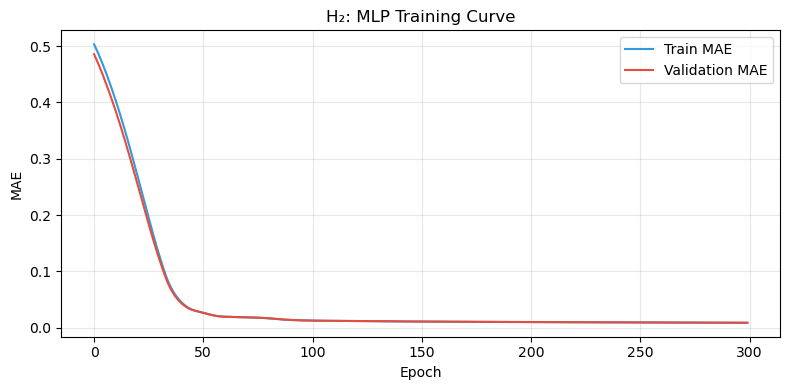

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_hist, label='Train MAE', color='#3498db')
ax.plot(val_hist, label='Validation MAE', color='#e74c3c')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE')
ax.set_title('H\u2082: MLP Training Curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Compare RF vs MLP

In [5]:
rf = joblib.load('rf_mlqem.joblib')
rf_test_pred = rf.predict(X_test_raw)
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)

print('=' * 52)
print(f'  Unmitigated MAE : {baseline_mae:.4f}')
print(f'  RF MAE          : {rf_test_mae:.4f}  ({baseline_mae/rf_test_mae:.1f}x improvement)')
print(f'  MLP MAE         : {mlp_test_mae:.4f}  ({baseline_mae/mlp_test_mae:.1f}x improvement)')
print(f'  Winner          : {"RF" if rf_test_mae < mlp_test_mae else "MLP"}')
print('=' * 52)

  Unmitigated MAE : 0.0349
  RF MAE          : 0.0084  (4.2x improvement)
  MLP MAE         : 0.0092  (3.8x improvement)
  Winner          : RF


## 5. Per-Observable Breakdown

In [6]:
print(f'{"Observable":<10} {"Unmitigated":>12} {"RF":>10} {"MLP":>10}')
print('-' * 44)

for obs_idx in ALL_OBS:
    label = PAULI_LABELS[obs_idx]
    symp = SYMPLECTIC[label]
    nf = qubit_noise_features(symp)
    N = len(noisy_test)

    feats_raw = np.column_stack([
        noisy_test[:, obs_idx], np.tile(symp, (N, 1)),
        np.full((N, 1), N_2Q), np.full((N, 1), N_SX),
        np.tile(nf, (N, 1)),
    ]).astype(np.float32)

    ideal_vals = ideal_test[:, obs_idx]
    noisy_vals = noisy_test[:, obs_idx]

    rf_corr = rf.predict(feats_raw)
    
    feats_sc = scaler.transform(feats_raw)
    model.eval()
    with torch.no_grad():
        mlp_corr = model(torch.tensor(feats_sc, dtype=torch.float32)).numpy().ravel()

    unm_mae = mean_absolute_error(ideal_vals, noisy_vals)
    rf_mae  = mean_absolute_error(ideal_vals, rf_corr)
    mlp_mae = mean_absolute_error(ideal_vals, mlp_corr)

    print(f'{label:<10} {unm_mae:>12.4f} {rf_mae:>10.4f} {mlp_mae:>10.4f}')

Observable  Unmitigated         RF        MLP
--------------------------------------------
IZ               0.0261     0.0084     0.0093
ZI               0.0220     0.0085     0.0082
ZZ               0.0469     0.0077     0.0101
XX               0.0446     0.0089     0.0093


## 6. Energy Reconstruction

In [7]:
coeffs = np.array(PAULI_COEFFS)
E_ideal = ideal_test @ coeffs
E_unm   = noisy_test @ coeffs

# RF corrected energy
rf_corrected = noisy_test.copy()
for obs_idx in ALL_OBS:
    label = PAULI_LABELS[obs_idx]
    symp = SYMPLECTIC[label]
    nf = qubit_noise_features(symp)
    N = len(noisy_test)
    feats = np.column_stack([
        noisy_test[:, obs_idx], np.tile(symp, (N, 1)),
        np.full((N, 1), N_2Q), np.full((N, 1), N_SX),
        np.tile(nf, (N, 1)),
    ]).astype(np.float32)
    rf_corrected[:, obs_idx] = rf.predict(feats)
E_rf = rf_corrected @ coeffs

# MLP corrected energy
mlp_corrected = noisy_test.copy()
model.eval()
for obs_idx in ALL_OBS:
    label = PAULI_LABELS[obs_idx]
    symp = SYMPLECTIC[label]
    nf = qubit_noise_features(symp)
    N = len(noisy_test)
    feats_raw = np.column_stack([
        noisy_test[:, obs_idx], np.tile(symp, (N, 1)),
        np.full((N, 1), N_2Q), np.full((N, 1), N_SX),
        np.tile(nf, (N, 1)),
    ]).astype(np.float32)
    feats_sc = scaler.transform(feats_raw)
    with torch.no_grad():
        mlp_corrected[:, obs_idx] = model(
            torch.tensor(feats_sc, dtype=torch.float32)).numpy().ravel()
E_mlp = mlp_corrected @ coeffs

print(f'Energy MAE on 200 test \u03b8 values:')
print(f'  Unmitigated : {mean_absolute_error(E_ideal, E_unm):.5f} Ha')
print(f'  RF          : {mean_absolute_error(E_ideal, E_rf):.5f} Ha')
print(f'  MLP         : {mean_absolute_error(E_ideal, E_mlp):.5f} Ha')
print(f'\n  Chemical accuracy: 0.00160 Ha')

Energy MAE on 200 test θ values:
  Unmitigated : 0.01555 Ha
  RF          : 0.00461 Ha
  MLP         : 0.00464 Ha

  Chemical accuracy: 0.00160 Ha
